#Entendiendo los métodos de Regulización

Ing. Mayarling Martínez Flores

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [12]:
# construccion de variables
x1 = np.arange(-1.3, 13.5, 0.125)

In [13]:
x2 = x1 * x1
X3 = x1 * x1 * x1

In [7]:
import pandas as pd

In [14]:
w = np.concatenate((np.vstack(X1), np.vstack(x2), np.vstack(X3)), axis=1)

In [15]:
X = pd.DataFrame(w, columns=['X1', 'X2', 'X3'])

In [16]:
X.head()

,X1,X2,X3
0,-1.300,1.690000,-2.197000
1,-1.175,1.380625,-1.622234
2,-1.050,1.102500,-1.157625
3,-0.925,0.855625,-0.791453
4,-0.800,0.640000,-0.512000


In [17]:
#coeficientes de la funcion polinómica
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3

In [18]:
# introducir ruido
noise = 200 * (random.random() - 0.5)

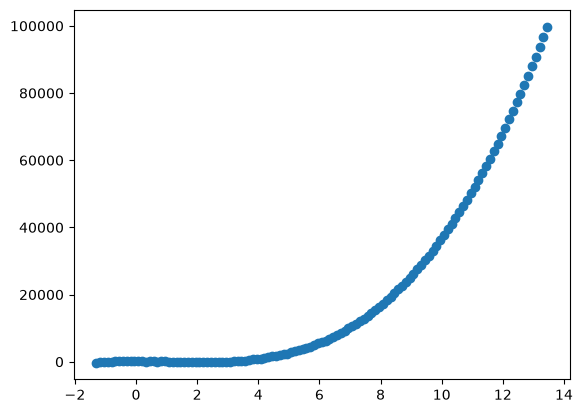

In [21]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)
  
  
plt.scatter(x1,yreal)
plt.show()

In [20]:
# modelos entrenados
modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))
modelos.append(('RIDGE', Ridge(alpha=30)))
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [23]:
yhat0 = [] #RLM
yhat1 = [] #LASSO
yhat2 = [] #RIDGE
yhat12 = [] #ElasticNet

In [24]:
for name, model in modelos:
  # entrenamos el modelo seleccionado y obtenemos sus predicciones:
  print("%s:" % name)
  mm = model.fit(X, np.ravel(yreal))
  yhat = mm.predict(X)
  
  print(mm.intercept_)   # por si deseas conocer w0.
  print(mm.coef_)       # despleguemos los pesos obtenidos

  if name=='LR':
    yhat0.append(yhat)
    print('\n')
  elif name=='LASSO':
    yhat1.append(yhat)
    print('\n')
  elif name=='RIDGE':
    yhat2.append(yhat)
    print('\n')
  else:
    yhat12.append(yhat)

LR:
181.71968903790912
[ -30.39616933 -163.90912428   53.2652212 ]


LASSO:
151.3615899955039
[  -4.39152022 -167.918083     53.43345386]


RIDGE:
176.48489614170103
[ -30.83045526 -163.34441805   53.22348882]


EN:
171.1438348962547
[ -32.40824841 -162.47868266   53.1646083 ]


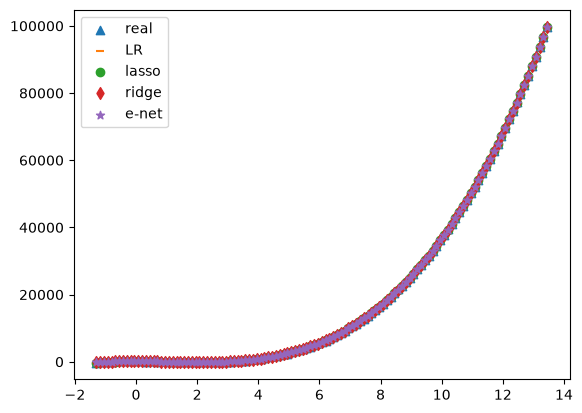

In [25]:
# visualización de los resultados obtenidos
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

plt.legend(loc=2)
plt.show()